In [162]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from copy import deepcopy

In [ ]:
resultsPath = os.path.join('.', "results/nudge/")

# last col median of all alphas
# last row median of all mus
# last cell global median

col = [0, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1.0, "mu median"]
row = [1e-5, 1e-15, 1e-30, "p median"]

In [164]:
template = pd.DataFrame(np.nan, index=row, columns=col, dtype=float)

iDlgLossTable = template.copy()
iDlgMseTable = template.copy()

DlgLossTable = template.copy()
DlgMseTable = template.copy()

tables = {
    "iDlgLoss": iDlgLossTable,
    "iDlgMse": iDlgMseTable,
    "DlgLoss": DlgLossTable,
    "DlgMse": DlgMseTable
}

In [ ]:
for folder in os.listdir(resultsPath):
    if os.path.isfile(os.path.join(resultsPath, folder)):
        continue
    parameters = folder.split('_')
    mu = float(parameters[0])
    alpha = float(parameters[1])
    results = os.path.join(resultsPath, folder, "results.csv")
    df = pd.read_csv(results)

    iDlgLossTable.loc[mu, alpha] = df.iloc[:, 3].median()
    iDlgMseTable.loc[mu, alpha] = df.iloc[:, 4].median()

    DlgLossTable.loc[mu, alpha] = df.iloc[:, 1].median()
    DlgMseTable.loc[mu, alpha] = df.iloc[:, 2].median()

1e-15 0.9
1e-15 0.75
1e-30 1.0
1e-05 0.9
1e-05 0.95
1e-30 0.99
1e-05 0.75
1e-15 0.95
1e-30 0.5
1e-30 0.999
1e-15 0.5
1e-30 0.75
1e-05 0.99
1e-05 0.5
1e-05 0.999
1e-30 0.0
1e-30 0.95
1e-15 0.0
1e-05 0.0
1e-30 0.9
1e-15 0.99


In [166]:
for name, table in tables.items():
    # table = pd.DataFrame(table)

    table["mu median"] = table.median(axis=1)

    pMedians = table.median(axis=0)
    pMedians.name = "p median"

    table.loc["p median"] = pMedians

    table.loc["p median", "mu median"] = table.iloc[:-1, :-1].stack().median()

    tables[name] = table

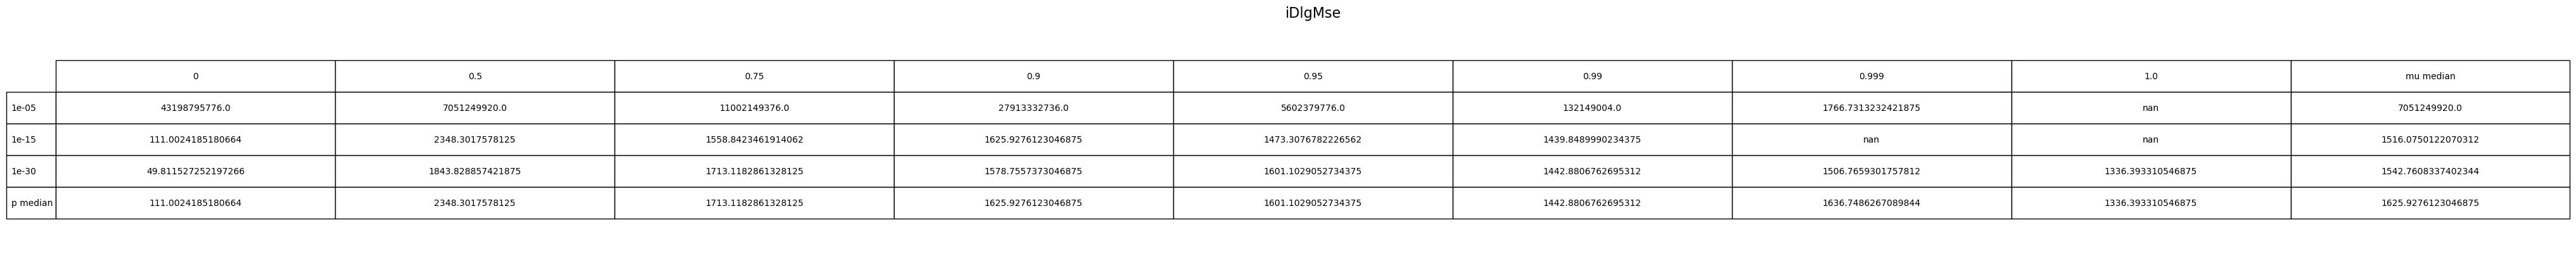

In [167]:
plot = "iDlgMse"

fig, ax = plt.subplots()
ax.axis("off")
table = ax.table(
    cellText=tables[plot],
    cellLoc="center",
    loc="center"
)
plt.title(plot, fontsize=16)

table.scale(8, 3)


plt.show()